# Zomato Restaurant Market Analysis

## Objective
The objective of this project is to analyze restaurant data for Delhi using a publicly available dataset. The analysis focuses on identifying restaurant density across localities, understanding ratings and pricing patterns, and generating business insights through data visualization.

## Business Questions Solved

1. Which localities have the highest restaurant concentration?
2. Which restaurant categories dominate the Delhi market?
3. What pricing trends exist across different areas?
4. Do higher-priced restaurants receive better ratings?
5. Which areas represent premium dining markets?
6. What customer rating patterns can be observed across restaurants?

# Executive Summary

This project analyzes Zomato restaurant data to identify market trends, restaurant density patterns, customer rating behavior, pricing distribution, and cuisine preferences across Delhi. The analysis aims to generate business insights that can help understand competitive restaurant markets and customer dining trends.

The project uses Python libraries such as Pandas, Matplotlib, and Seaborn for data cleaning, exploratory data analysis (EDA), and visualization.

In [100]:
# Setting visualization style

sns.set_style("whitegrid")


# Importing required libraries

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

The dataset is loaded using the Pandas library. This dataset contains restaurant-related information such as restaurant names, locality, ratings, and pricing details.

In [104]:
df = pd.read_csv("DELHINCR Restaurants.csv")   # replace with exact csv name
df.head()

,Restaurant_Name,Category,Pricing_for_2,Locality,Dining_Rating,Dining_Review_Count,Delivery_Rating,Delivery_Rating_Count,Website,Address,Phone_No,Latitude,Longitude,Known_For2,Known_For22
0,Rustom's,"Parsi, Street Food, North Indian, Desserts, Be...",2100,"ITO, New Delhi",4.9,1885,4.4,1844,https://www.zomato.com/ncr/rustoms-ito-new-delhi,"Delhi Parsi Anjuman, LNJP Colony, Bahadur Shah...",9.1991E+11,28.638167,77.240472,NaN,NaN
1,Cafe Lota,"Cafe, South Indian, North Indian, Beverages",1200,"Pragati Maidan, New Delhi",4.9,3748,3.9,37,https://www.zomato.com/ncr/cafe-lota-pragati-m...,"National Crafts Museum, Gate 2, Bhairon Marg, ...",9.17839E+11,28.613429,77.242471,"Pondicherry Fish Curry, Coconut Rabdi, Sabudan...","Artistic Decor, The Service, Natural Ambience,..."
2,Dum-Pukht - ITC Maurya,"Mughlai, North Indian, Desserts",5000,"ITC Maurya, Chanakyapuri, New Delhi",4.9,1371,NaN,0,https://www.zomato.com/ncr/dum-pukht-itc-maury...,"ITC Maurya, Chanakyapuri, New Delhi",9.11146E+11,28.598200,77.173661,"Royal ambiance and Mughlai cuisine, also recei...",NaN
3,Burma Burma,"Asian, Burmese, Bubble Tea, Desserts, Salad",1600,"Cyber Hub, DLF Cyber City, Gurgaon",4.9,2636,4.4,1238,https://www.zomato.com/ncr/burma-burma-dlf-cyb...,"Shop 6, Ground Floor, Building 8, Tower C, Cyb...",9.11244E+11,28.494464,77.088532,"Coconut Milk Dessert, Honey Caviar, Kaffir Lim...","Knowledgeable Staff, Authentic, Soothing Ambie..."
4,The Big Chill,"Continental, American, Italian",1500,"Khan Market, New Delhi",4.9,6487,NaN,0,https://www.zomato.com/ncr/the-big-chill-khan-...,"68-A, Khan Market, New Delhi",9.11142E+11,28.600350,77.227493,"Irish Cream Tiramisu, Penne Vodka, Mississippi...","Retro Ambience, Yummy Desserts, Big Portions, ..."


## Dataset Overview

This section provides a quick overview of the dataset structure including the number of rows, columns, and available features.

In [106]:
# Checking dataset dimensions

df.shape

(1965, 15)

In [107]:
# Viewing column names

df.columns

Index(['Restaurant_Name', 'Category', 'Pricing_for_2', 'Locality',
       'Dining_Rating', 'Dining_Review_Count', 'Delivery_Rating',
       'Delivery_Rating_Count', 'Website', 'Address', 'Phone_No', 'Latitude',
       'Longitude', 'Known_For2', 'Known_For22'],
      dtype='object')

## Data Cleaning

Before analysis, the dataset needs to be cleaned to ensure consistency and accuracy. Column names are standardized and missing values in important columns are removed.

In [109]:
# Standardizing column names

df.columns = df.columns.str.lower().str.replace(" ", "_")

# Viewing updated column names
df.columns

Index(['restaurant_name', 'category', 'pricing_for_2', 'locality',
       'dining_rating', 'dining_review_count', 'delivery_rating',
       'delivery_rating_count', 'website', 'address', 'phone_no', 'latitude',
       'longitude', 'known_for2', 'known_for22'],
      dtype='object')

In [110]:
# Checking missing values

df.isnull().sum()

restaurant_name            0
category                   0
pricing_for_2              0
locality                   0
dining_rating              0
dining_review_count        0
delivery_rating          402
delivery_rating_count      0
website                    0
address                    0
phone_no                   0
latitude                   0
longitude                  0
known_for2               405
known_for22              841
dtype: int64

In [111]:
# Removing rows with missing important values

df = df.dropna(subset=['restaurant_name', 'locality'])

## Total Number of Restaurants

The total number of restaurants available in the dataset after cleaning is calculated below.

In [113]:
# Finding top restaurant localities

top_areas = df['locality'].value_counts().head(10)

top_areas

locality
Connaught Place, New Delhi               69
Rohini, New Delhi                        34
Sector 29, Gurgaon                       31
Rajouri Garden, New Delhi                31
Punjabi Bagh, New Delhi                  26
Delhi University-GTB Nagar, New Delhi    26
Safdarjung, New Delhi                    24
Janakpuri, New Delhi                     22
Raj Nagar, Ghaziabad                     21
Indirapuram, Ghaziabad                   21
Name: count, dtype: int64

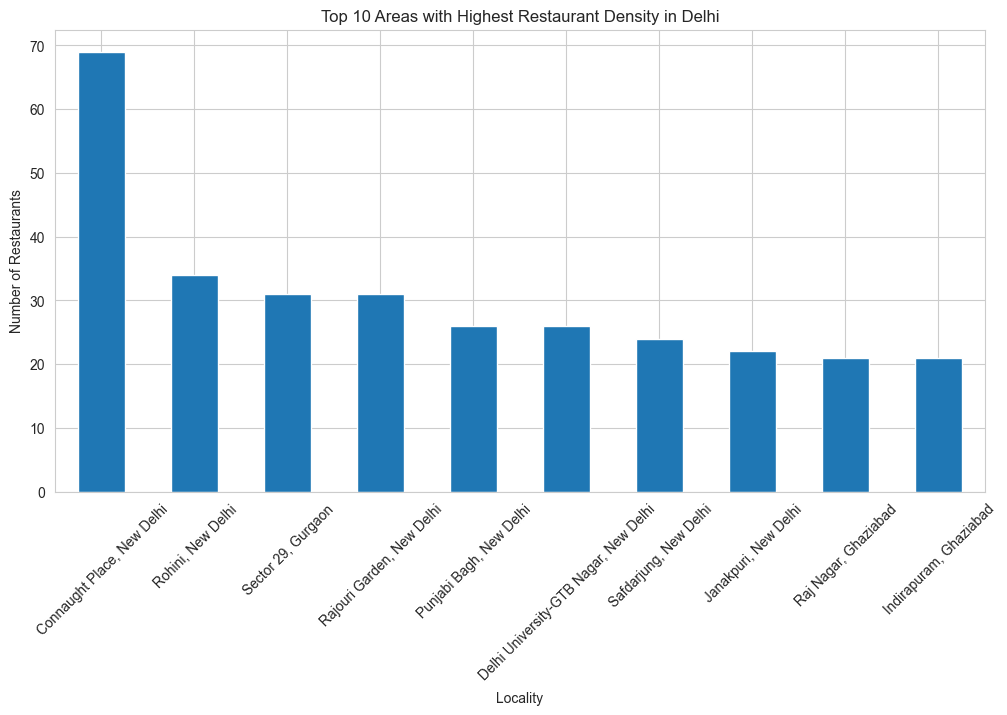

In [114]:
# Visualizing top restaurant localities

plt.figure(figsize=(12,6))

top_areas.plot(kind='bar')

plt.title("Top 10 Areas with Highest Restaurant Density in Delhi")
plt.xlabel("Locality")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

### Insight

Commercial and central food hubs show the highest restaurant density, indicating strong customer demand and intense market competition in these regions.

## Dining Rating Analysis

Dining ratings help evaluate customer satisfaction and restaurant quality. This section analyzes the distribution of restaurant ratings.

In [116]:
# Summary statistics for dining ratings

df['dining_rating'].describe()

count    1965.000000
mean        4.140000
std         0.202147
min         3.900000
25%         4.000000
50%         4.100000
75%         4.300000
max         4.900000
Name: dining_rating, dtype: float64

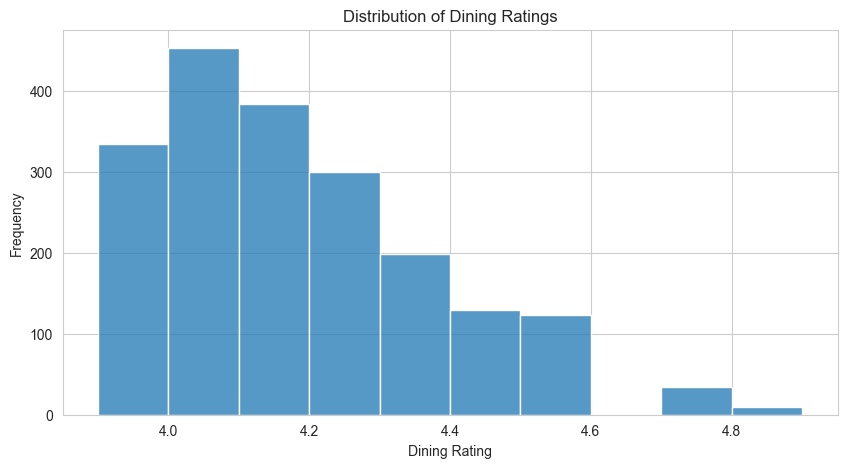

In [117]:
# Distribution of dining ratings

plt.figure(figsize=(10,5))

sns.histplot(df['dining_rating'], bins=10)

plt.title("Distribution of Dining Ratings")
plt.xlabel("Dining Rating")
plt.ylabel("Frequency")

plt.show()

## Pricing Analysis

Pricing for two people provides insight into restaurant affordability and market segmentation across Delhi.

In [119]:
# Summary statistics for pricing

df['pricing_for_2'].describe()

count    1965.000000
mean     1090.687023
std       934.481617
min       100.000000
25%       500.000000
50%       700.000000
75%      1500.000000
max      8000.000000
Name: pricing_for_2, dtype: float64

### Insight

Pricing distribution indicates the presence of both premium and budget-friendly dining markets across Delhi, reflecting diverse customer segments and purchasing behavior.

## Top Rated Restaurants

This section highlights some of the highest-rated restaurants in the dataset.

In [121]:
# Top rated restaurants

top_rated = df.sort_values(by='dining_rating', ascending=False).head(10)

top_rated[['restaurant_name', 'locality', 'dining_rating']]

,restaurant_name,locality,dining_rating
0,Rustom's,"ITO, New Delhi",4.9
1,Cafe Lota,"Pragati Maidan, New Delhi",4.9
2,Dum-Pukht - ITC Maurya,"ITC Maurya, Chanakyapuri, New Delhi",4.9
3,Burma Burma,"Cyber Hub, DLF Cyber City, Gurgaon",4.9
4,The Big Chill,"Khan Market, New Delhi",4.9
5,Carnatic Cafe,"Lodhi Colony, New Delhi",4.9
6,"Cocktails & Dreams, Speakeasy","Sector 15, Gurgaon",4.9
7,Natural Ice Cream,"Connaught Place, New Delhi",4.9
8,Kuremal Mohan Lal Kulfi Wale,"Chawri Bazar, New Delhi",4.9
9,Juggernaut,"Kailash Colony, New Delhi",4.8


## Key Insights

1. Major commercial areas and central food hubs show the highest restaurant density.
2. Most restaurants have ratings between 3.5 and 4.5, indicating competitive service quality.
3. Pricing varies significantly, showing the presence of both premium and budget-friendly dining options.
4. High-density restaurant clusters indicate strong customer demand and competitive food markets.
5. Restaurant ratings and locality trends can help businesses identify potential market opportunities.

## Cuisine Analysis

This section identifies the most popular cuisines available across restaurants in Delhi.

In [140]:
top_cuisines = df['category'].value_counts().head(10)

top_cuisines

category
North Indian                        88
North Indian, Chinese               39
North Indian, Mughlai               37
Pizza, Fast Food                    19
North Indian, Chinese, Mughlai      17
North Indian, Chinese, Fast Food    17
Bakery, Desserts                    15
North Indian, Mughlai, Chinese      14
South Indian                        13
North Indian, Rolls                 12
Name: count, dtype: int64

### Insight

Popular restaurant categories dominate the market, highlighting customer dining preferences and competitive cuisine segments within Delhi's restaurant ecosystem.

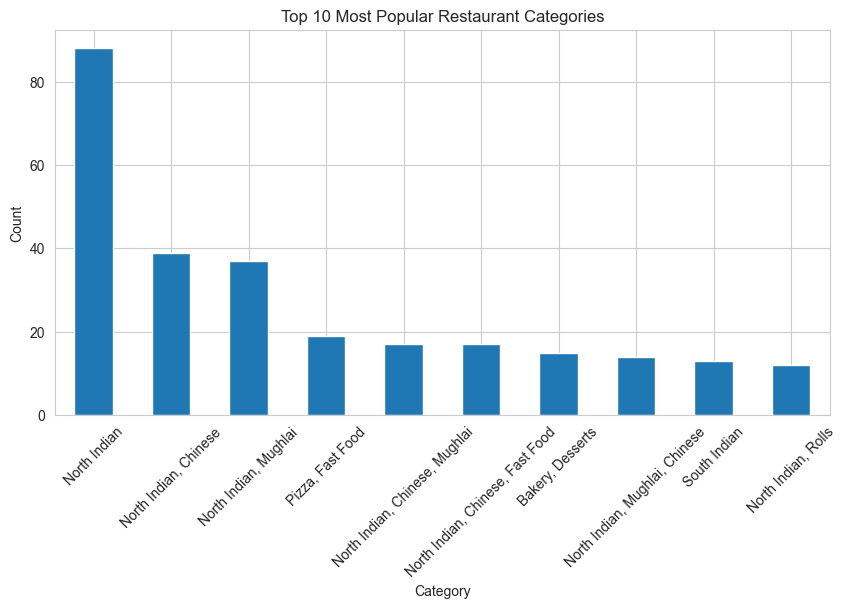

In [142]:
plt.figure(figsize=(10,5))

top_cuisines.plot(kind='bar')

plt.title("Top 10 Most Popular Restaurant Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## Average Pricing by Locality

This section analyzes the average pricing trends across major restaurant localities.

In [145]:
avg_price = df.groupby('locality')['pricing_for_2'].mean().sort_values(ascending=False).head(10)

avg_price

locality
The Oberoi, Udyog Vihar, Gurgaon                   4833.333333
ITC Maurya, Chanakyapuri, New Delhi                4820.000000
Taj Palace, Chanakyapuri, New Delhi                4780.000000
The Roseate, Kapashera, New Delhi                  4750.000000
The Lalit New Delhi, Barakhamba Road, New Delhi    4650.000000
The Park, Connaught Place, New Delhi               4500.000000
The Imperial, Janpath, New Delhi                   4250.000000
Trident, Udyog Vihar, Gurgaon                      4100.000000
The Taj Mahal Hotel, Mansingh Road, New Delhi      4040.000000
The Oberoi, Dr. Zakir Hussain Marg, New Delhi      4000.000000
Name: pricing_for_2, dtype: float64

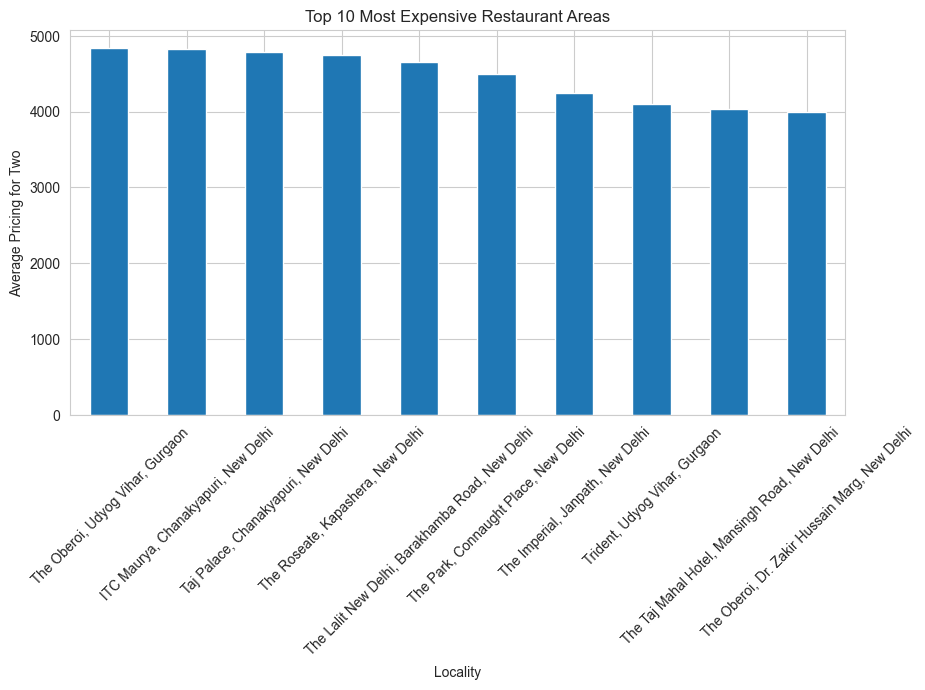

In [147]:
plt.figure(figsize=(10,5))

avg_price.plot(kind='bar')

plt.title("Top 10 Most Expensive Restaurant Areas")
plt.xlabel("Locality")
plt.ylabel("Average Pricing for Two")

plt.xticks(rotation=45)

plt.show()

## Relationship Between Pricing and Ratings

This section explores whether higher-priced restaurants tend to receive better ratings.

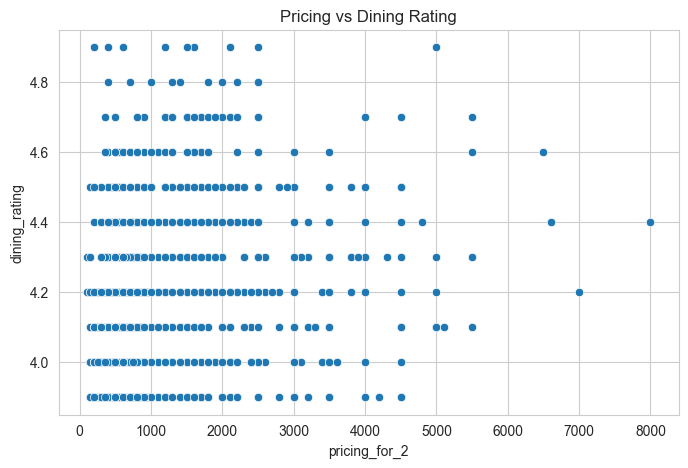

In [150]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='pricing_for_2', y='dining_rating', data=df)

plt.title("Pricing vs Dining Rating")

plt.show()

## Correlation Analysis

The heatmap below shows relationships between numerical variables in the dataset.

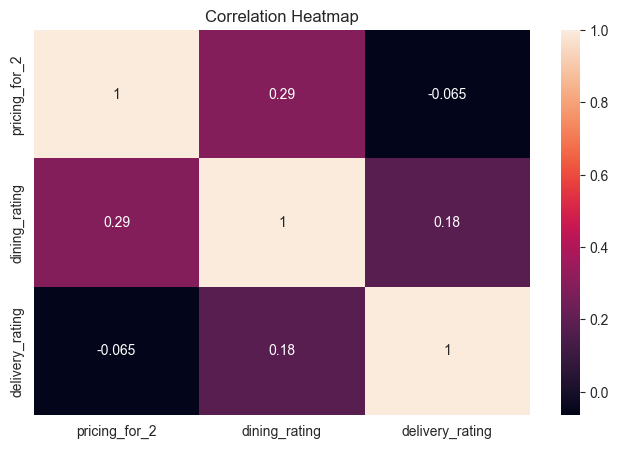

In [153]:
numeric_df = df[['pricing_for_2', 'dining_rating', 'delivery_rating']]

plt.figure(figsize=(8,5))

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()

### Insight

The relationship between pricing and ratings suggests that higher-priced restaurants do not always guarantee significantly better customer ratings, indicating the importance of service quality and customer experience.

# Delivery vs Dining Ratings

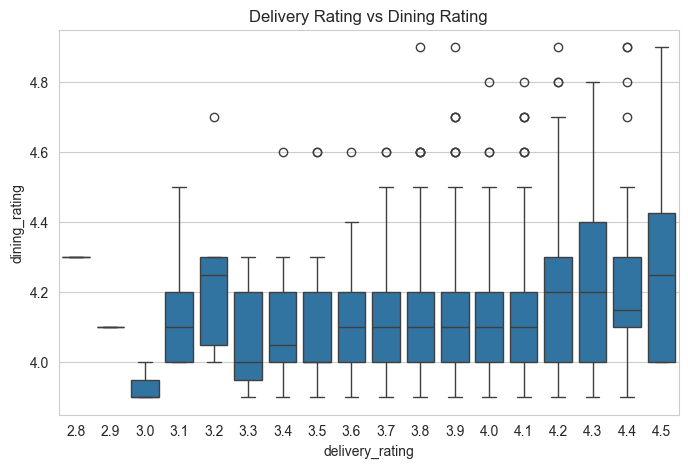

In [155]:
plt.figure(figsize=(8,5))

sns.boxplot(x='delivery_rating', y='dining_rating', data=df)

plt.title("Delivery Rating vs Dining Rating")

plt.show()

## Business Impact

The insights generated from this analysis can help restaurant businesses, food delivery platforms, and market researchers better understand customer preferences, competitive regions, pricing strategies, and market opportunities within Delhi's restaurant industry.

# Conclusion

This project successfully analyzed restaurant data for Delhi using Python-based data analysis and visualization techniques. The dataset was cleaned and processed to ensure accurate and reliable analysis. Multiple aspects of the restaurant market were explored, including restaurant density across localities, customer ratings, pricing trends, cuisine distribution, and relationships between numerical variables.

The analysis identified major restaurant hubs with high market concentration and revealed that most restaurants maintain moderate to high customer ratings. Pricing analysis showed the presence of both premium and budget-friendly dining options across different areas of Delhi. Cuisine analysis further highlighted popular restaurant categories and customer preferences.

Various visualizations such as bar charts, histograms, scatter plots, and heatmaps were used to present insights clearly and effectively. Overall, this project demonstrates practical skills in data cleaning, exploratory data analysis (EDA), data visualization, and business insight generation using Python libraries including Pandas, Matplotlib, and Seaborn.